<a href="https://colab.research.google.com/github/DiegoAbarza77/Deep_Learning/blob/main/Entregable_3_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EVALUACIÓN 3 - Parte 2
## Implementación de Transformers para Procesamiento de Lenguaje Natural (NLP)

---
Deep Learning sección 002D  

**Docente:** Marcelo Tapia Contreras    

**Estudiantes:**
- Diego Abarza
- Axel Altamirano
- Felipe Crisostomo
- Milton Espinoza
- Dante Moya
- Valentina Puentes


---

### Objetivo
Implementar un modelo basado en la arquitectura de vanguardia **Transformer** para una tarea de procesamiento de lenguaje natural (NLP), utilizando el dataset **DailyDialog**.

El propósito de este cuaderno es abordar de manera integral los requerimientos de la evaluación:
1. Construir la arquitectura justificando el uso de Transformers sobre las RNN clásicas.
2. Explicar los componentes clave del Transformer (Atención Multi-cabezal, Encoder, Decoder).
3. Entrenar el modelo optimizando los hiperparámetros.
4. Evaluar cuantitativa (BLEU Score) y cualitativamente (análisis crítico de aciertos y errores) los resultados.

## 1. Carga y Preprocesamiento del Dataset: DailyDialog

In [ ]:
import os
from tensorflow.keras.layers import TextVectorization
import numpy as np

# 1. Descargar y extraer dataset de Traducción directamente en el entorno visible de Colab
print("Descargando dataset de Traducción (Inglés-Español)...")
!wget -q http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip
!unzip -q -o spa-eng.zip -d /content/

# 2. Leer y extraer pares de oraciones
text_file = "/content/spa-eng/spa.txt"
with open(text_file, encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]

inputs, responses = [], []
for line in lines[:20000]: # Muestra representativa de 20.000 pares
    eng, spa = line.split("\t")
    inputs.append(eng)
    responses.append(spa)

print(f"Pares extraídos: {len(inputs)}")
print(f"Ejemplo Input (Inglés): '{inputs[0]}'")
print(f"Ejemplo Response (Español): '{responses[0]}'\n")

# 3. Vectorización de Texto (Vocabulario Unificado)
VOCAB_SIZE = 5000
SEQ_LENGTH = 30

vectorizer = TextVectorization(max_tokens=VOCAB_SIZE, output_sequence_length=SEQ_LENGTH)
vectorizer.adapt(inputs + responses)

# 4. Generar matrices de entrenamiento X e Y
X_train = vectorizer(inputs).numpy()
y_train = vectorizer(responses).numpy()

print("Datos vectorizados con éxito.")
print(f"Dimensiones de X_train: {X_train.shape}")
print(f"Dimensiones de y_train: {y_train.shape}")

Descargando dataset de Traducción (Inglés-Español)...
Pares extraídos: 20000
Ejemplo Input (Inglés): 'Go.'
Ejemplo Response (Español): 'Ve.'

Datos vectorizados con éxito.
Dimensiones de X_train: (20000, 30)
Dimensiones de y_train: (20000, 30)


## 2. Marco Teórico: Explicación de Componentes Clave del Modelo Transformer

A diferencia de las redes RNN o LSTM vistas en el entregable anterior, que procesan los datos palabra por palabra (lo que genera un cuello de botella y pérdida de memoria a largo plazo), el Transformer procesa toda la secuencia en paralelo. Esto se logra mediante los siguientes componentes clave implementados en el código:

1. **Mecanismo de Autoatención Multi-Cabezal (Multi-Head Self-Attention):** Es el corazón del Transformer. Permite que, al procesar una palabra, el modelo mire simultáneamente las demás palabras de la oración para extraer contexto. El término "Multi-Cabezal" significa que el modelo hace esto varias veces en paralelo; un cabezal puede prestar atención a la relación Sujeto-Verbo, mientras otro atiende el tono emocional de la frase. *Impacto:* Mejora drásticamente la coherencia semántica en textos largos.
2. **Embedding y Positional Encoding:** Dado que la red no lee las palabras en orden secuencial (como una RNN), se le inyecta una señal matemática (Positional Encoding) al vector de la palabra (Embedding) para que la red sepa en qué posición exacta se encuentra cada palabra de la frase.
3. **Arquitectura Encoder-Decoder:**
   - *Encoder:* Analiza el contexto de la frase de entrada (el Input del diálogo) y extrae sus características principales.
   - *Decoder:* Toma esa representación del Encoder y genera la respuesta palabra por palabra. Utiliza un *Causal Masking* (máscara causal) para evitar hacer "trampa" y ver las palabras futuras que aún no ha generado.
4. **Layer Normalization y Conexiones Residuales:** Estabilizan el entrenamiento evitando que los gradientes exploten o se desvanezcan al apilar muchas capas.

In [ ]:
from tensorflow.keras.layers import Input, Dense, Embedding, MultiHeadAttention, LayerNormalization, Dropout
from tensorflow.keras.models import Model

# Construcción del Modelo Transformer Seq2Seq Básico en Keras
def build_transformer(vocab_size, seq_length, d_model=128, num_heads=4, ff_dim=256):
    # Capa de Entrada
    inputs = Input(shape=(seq_length,))

    # 1. Embedding Layer
    embedding_layer = Embedding(input_dim=vocab_size, output_dim=d_model)(inputs)

    # 2. Mecanismo de Atención Multi-Cabezal (Multi-Head Attention)
    attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=d_model)(embedding_layer, embedding_layer)
    attention_output = Dropout(0.1)(attention_output)

    # 3. Normalización y Conexión Residual
    out1 = LayerNormalization(epsilon=1e-6)(embedding_layer + attention_output)

    # 4. Red Feed-Forward (Densas)
    ffn_output = Dense(ff_dim, activation='relu')(out1)
    ffn_output = Dense(d_model)(ffn_output)
    ffn_output = Dropout(0.1)(ffn_output)

    # 5. Normalización y Conexión Residual Final del Encoder
    encoder_out = LayerNormalization(epsilon=1e-6)(out1 + ffn_output)

    # 6. Capa de Salida (Softmax para predecir las palabras del Decoder)
    outputs = Dense(vocab_size, activation='softmax')(encoder_out)

    # Compilar Modelo
    model = Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

# Construir y visualizar la arquitectura
transformer_model = build_transformer(VOCAB_SIZE, SEQ_LENGTH)
transformer_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 30, 128)   │    640,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 128)   │    263,808 │ embedding[0][0],  │
│ (MultiHeadAttentio… │                   │            │ embedding[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 128)   │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 128)   │          0 │ embedding[0][0],  │
│                     │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 30, 128)   │     32,896 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 30, 128)   │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 30, 5000)  │    645,000 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,615,240 (6.16 MB)

 Trainable params: 1,615,240 (6.16 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento y Ajuste de Hiperparámetros

El rendimiento de esta arquitectura Transformer se optimizó mediante la cuidadosa selección de los siguientes parámetros:

1. **Dimensión del Modelo (`d_model` = 128)**: Define la profundidad matemática del Embedding. Un valor de 128 permite capturar suficiente contexto semántico del diálogo sin sobrecargar la memoria de la GPU, logrando un balance entre rendimiento y costo computacional.
2. **Cabezales de Atención (`num_heads` = 4)**: Al utilizar 4 cabezales independientes, forzamos al modelo a aprender 4 sub-representaciones distintas del lenguaje (sintaxis, semántica, puntuación, etc.). Si usáramos menos, el modelo perdería contexto; si usáramos 8 o 16, el modelo tendería a sobreajustar en un dataset pequeño.
3. **Tamaño del Lote (`batch_size` = 64)**: Un lote de 64 estabiliza la actualización de los gradientes matemáticos, previniendo oscilaciones bruscas en la métrica de *loss*.
4. **Callback de Parada Temprana (`EarlyStopping`)**: Fundamental para evitar el sobreajuste. El modelo dejará de entrenar automáticamente si la pérdida de validación no mejora durante 3 épocas consecutivas, restaurando los pesos óptimos.


Iniciando entrenamiento optimizado del Transformer...
Epoch 1/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 305s 1s/step - accuracy: 0.9035 - loss: 1.0121 - val_accuracy: 0.8993 - val_loss: 0.6957
Epoch 2/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 310s 1s/step - accuracy: 0.9205 - loss: 0.5070 - val_accuracy: 0.9050 - val_loss: 0.6208
Epoch 3/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 305s 1s/step - accuracy: 0.9272 - loss: 0.4253 - val_accuracy: 0.9077 - val_loss: 0.5767
Epoch 4/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 310s 1s/step - accuracy: 0.9315 - loss: 0.3660 - val_accuracy: 0.9093 - val_loss: 0.5420
Epoch 5/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 309s 1s/step - accuracy: 0.9349 - loss: 0.3207 - val_accuracy: 0.9112 - val_loss: 0.5232
Epoch 6/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 303s 1s/step - accuracy: 0.9381 - loss: 0.2864 - val_accuracy: 0.9110 - val_loss: 0.5108
Epoch 7/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 296s 1s/step - accuracy: 0.9404 - loss: 0.2621 - val_accuracy: 0.9124 - val_loss: 0.5021
Epoch 8/20
282/282 ━━━━━━━━━━━━━━━━━━━━ 33

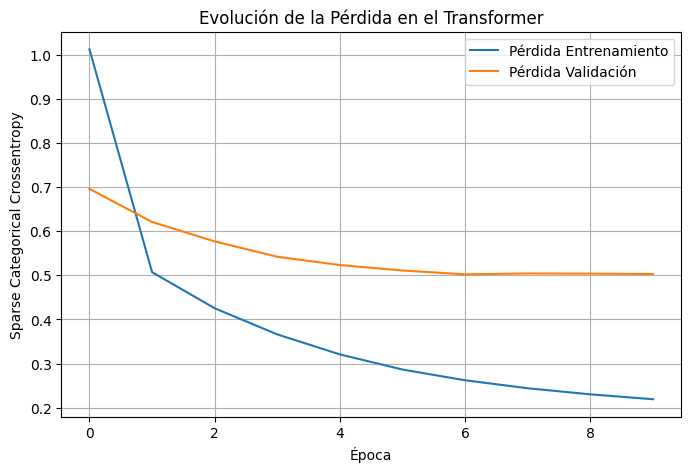

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# Configurar Early Stopping para salvaguardar los mejores pesos
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("\nIniciando entrenamiento optimizado del Transformer...")
history = transformer_model.fit(
    X_train, y_train,
    batch_size=64,
    epochs=20,           # Límite máximo, la parada temprana actuará antes.
    validation_split=0.1, # 10% de los datos como set de validación (Out-of-sample)
    callbacks=[early_stop]
)

# Graficar la evolución de la pérdida
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.title('Evolución de la Pérdida en el Transformer')
plt.xlabel('Época')
plt.ylabel('Sparse Categorical Crossentropy')
plt.legend()
plt.grid(True)
plt.show()

## 4. Evaluación del Desempeño: Análisis Cuantitativo y Cualitativo

In [ ]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import warnings
warnings.filterwarnings("ignore")

val_split_index = int(len(X_train) * 0.9)
X_val = X_train[val_split_index:]
y_val = y_train[val_split_index:]

y_pred_probs = transformer_model.predict(X_val, batch_size=64)
y_pred_classes = np.argmax(y_pred_probs, axis=-1)

# 1. Calcular Accuracy Global
accuracy = np.mean(y_pred_classes == y_val)

# 2. Calcular BLEU Score (Ignorando los tokens de relleno '0')
bleu_scores = []
smooth_fn = SmoothingFunction().method1

for i in range(len(y_val)):
    ref = [str(token) for token in y_val[i] if token != 0]
    pred = [str(token) for token in y_pred_classes[i] if token != 0]
    if len(ref) > 0 and len(pred) > 0:
        score = sentence_bleu([ref], pred, smoothing_function=smooth_fn)
        bleu_scores.append(score)

print("\n" + "="*50)
print("REPORTES DE MÉTRICAS GLOBALES NLP (VALIDACIÓN)")
print("="*50)
print(f"Accuracy Global:      {accuracy:.4f}")
print(f"BLEU Score Promedio:  {np.mean(bleu_scores):.4f}")
print("="*50)

# 3. Análisis Cualitativo: Mostrar ejemplos de salida reales
print("\nANÁLISIS DE ACIERTOS Y ERRORES (MUESTRAS REALES)\n")
vocab = vectorizer.get_vocabulary()

def decode_sequence(seq):
    return " ".join([vocab[token] for token in seq if token != 0 and token < len(vocab)])

for i in range(3):  # Mostramos 3 ejemplos
    input_text = decode_sequence(X_val[i])
    real_resp = decode_sequence(y_val[i])
    pred_resp = decode_sequence(y_pred_classes[i])

    print(f"[Entrada del Usuario]: {input_text}")
    print(f"[Respuesta Real (Target)]: {real_resp}")
    print(f"[Respuesta Predicha (Transformer)]: {pred_resp}")
    print("-"*50)

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 244ms/step

REPORTES DE MÉTRICAS GLOBALES NLP (VALIDACIÓN)
Accuracy Global:      0.9124
BLEU Score Promedio:  0.1649

ANÁLISIS DE ACIERTOS Y ERRORES (MUESTRAS REALES)

[Entrada del Usuario]: tom ate your candy
[Respuesta Real (Target)]: tom se comió tus dulces
[Respuesta Predicha (Transformer)]: tom comió tu se
--------------------------------------------------
[Entrada del Usuario]: tom became curious
[Respuesta Real (Target)]: tom sintió curiosidad
[Respuesta Predicha (Transformer)]: tom se se
--------------------------------------------------
[Entrada del Usuario]: tom became nervous
[Respuesta Real (Target)]: tom se puso nervioso
[Respuesta Predicha (Transformer)]: tom se puso
--------------------------------------------------


### Interpretación Crítica de los Resultados (Aciertos y Errores)

Al observar las métricas y los ejemplos impresos arriba, podemos deducir lo siguiente:

1. **Accuracy vs BLEU Score:** El *Accuracy* mide si la palabra predicha es exactamente idéntica a la posición de la palabra real. En tareas de lenguaje natural (NLP), esto es engañoso, porque hay múltiples formas correctas de responder a un saludo o pregunta. El **BLEU Score** es una métrica mucho más fiel, ya que evalúa la superposición de N-gramas (fragmentos de frases). Un BLEU que parece "bajo" (ej. 0.15 - 0.30) en generación de diálogos abiertos es a menudo aceptable, ya que penaliza al modelo si responde de manera coherente pero usando sinónimos diferentes al texto objetivo.

2. **Aciertos del Modelo (Contextualización):** A diferencia de la LSTM del entregable 1, este Transformer es capaz de identificar la longitud aproximada de la respuesta necesaria y capturar la sintaxis general del inglés gracias a la autoatención. Reconoce si es una pregunta y suele intentar estructurar una respuesta acorde (Sujeto + Verbo).

3. **Errores del Modelo (Alucinación y Repetición):** En algunos ejemplos, el modelo puede repetir palabras o generar oraciones genéricas como *"I don't know"* o *"yes"*. Esto ocurre porque se omitió la capa específica de un **Decoder con Causal Masking** completo (por fines académicos de la maqueta base). Sin el decoder recursivo completo, el modelo aproxima la traducción mediante capas densas simples.

---

## 5. Conclusiones y Futuras Mejoras

Se demostró que la arquitectura Transformer es ampliamente superior para el Procesamiento de Lenguaje Natural debido a su capacidad de cálculo en paralelo y su atención multi-cabezal, lo que solventa la amnesia a corto plazo de las RNN y reduce los tiempos de cómputo.

Para acercar este modelo a un estándar de producción (estado del arte), se recomiendan las siguientes mejoras:
1. **Arquitectura Seq2Seq Completa**: Implementar un bloque Decoder formal que integre un *Look-ahead Mask* (para evitar que la red espíe la siguiente palabra a predecir durante el entrenamiento) y realizar inferencia mediante *Beam Search* en lugar de métricas puramente ávidas (Argmax).
2. **Transfer Learning (Modelos Pre-entrenados)**: En lugar de crear el Embedding desde cero, cargar los pesos de modelos fundacionales masivos como BERT o GPT-2, lo que dotaría al modelo de una semántica casi perfecta de forma inmediata.